In [24]:
# Install dependencies if necessary.
%pip install pandas numpy matplotlib seaborn scipy openpyxl

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from great_tables import GT, md, style, loc

# Load data
df = pd.read_excel("C:/Users/ryadl/Desktop/EMFIT_local/Emfit/documentation/MS_Metadata.xlsx", 
                   sheet_name=3)

print(df.head(30))
print(df.columns.tolist())

   subject  Subject Group   EASI  Male   Age Age (MRI)  Onset before 2  \
0      MS1  sub-001     2     17   1.0  16.0       NaN             0.0   
1      MS2  sub-002     2    7.8   1.0  18.0       NaN             0.0   
2      MS3  sub-003     2    3.6   0.0  15.0       NaN             1.0   
3    MS4V1  sub-004     1   13.6   0.0  16.0       NaN             1.0   
4    MS4V2      NaN     1   12.8   0.0   NaN       NaN             NaN   
5      MS5  sub-005     2  17.25   1.0  12.0       NaN             1.0   
6      MS6  sub-006     2    0.8   1.0  17.0       NaN             1.0   
7      MS7  sub-007     2   16.6   0.0  13.0       NaN             1.0   
8      MS8  sub-008     2    2.2   0.0  16.0       NaN             1.0   
9      MS9  sub-009     2    2.4   1.0  16.0       NaN             0.0   
10    MS10  sub-010     3      0   0.0  16.0       NaN             NaN   
11    MS12  sub-012     3      0   1.0  15.0       NaN             NaN   
12    MS14  sub-014     2      3   0.0

In [26]:
# Drop unnamed columns
df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed')])

# Drop Subject column - redundant with subject
df = df.drop(columns=['Subject'])

# Drops any subject rows with NA.
df = df[df['subject'].notna()]

# Forward fill V2 style rows - inherit demographics from V1
df['Age'] = df['Age'].ffill()
df['Male'] = df['Male'].ffill()
df['Onset before 2'] = df['Onset before 2'].ffill()

# Create binary eczema vs control group
df['group_binary'] = df['Group'].apply(lambda x: 'eczema' if x in [1, 2] else 'control')

# Drop V2 rows to avoid duplicate participants in demographic analysis
df = df[~df['subject'].str.contains('V2', na=False)]

print(df['group_binary'].value_counts())
print(df.shape)

group_binary
eczema     49
control    27
Name: count, dtype: int64
(76, 8)


In [27]:
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

eczema = df[df['group_binary'] == 'eczema']
control = df[df['group_binary'] == 'control']

# Mann-Whitney U for continuous variable
age_stat, age_p = mannwhitneyu(eczema['Age'].dropna(), control['Age'].dropna(), alternative='two-sided')

# Chi-square for gender — expected cell counts all ≥5, assumption met
gender_table = pd.crosstab(df['group_binary'], df['Male'])
gender_chi2, gender_p, gender_dof, gender_expected = chi2_contingency(gender_table)

# Onset before 2 only within eczema group — Fisher's exact retained,
# smallest expected cell count (3) falls below the chi-square threshold
onset_table = pd.crosstab(eczema['Group'], eczema['Onset before 2'].dropna())
onset_OR, onset_p = fisher_exact(onset_table)

print("=== Statistical Comparisons: Eczema vs Control ===")
print(f"Age:            U={age_stat:.1f}, p={age_p:.4f}")
print(f"Gender (Male):  chi2={gender_chi2:.2f}, dof={gender_dof}, p={gender_p:.4f}")
print(f"\n=== Onset before 2 (Eczema only: Severe vs Moderate) ===")
print(f"Onset <2yrs:    OR={onset_OR:.2f}, p={onset_p:.4f}  (Fisher's exact — low cell count)")

print("==== Gender Table =====")
print(gender_table)
print("==== =====")
print(pd.crosstab(eczema['Group'], eczema['Onset before 2'].dropna())) # Proves that onset before 2 doesn't distinguish severe from moderate eczema.

=== Statistical Comparisons: Eczema vs Control ===
Age:            U=479.5, p=0.0452
Gender (Male):  chi2=0.00, dof=1, p=0.9748

=== Onset before 2 (Eczema only: Severe vs Moderate) ===
Onset <2yrs:    OR=0.78, p=1.0000  (Fisher's exact — low cell count)
==== Gender Table =====
Male          0.0  1.0
group_binary          
control        14   13
eczema         27   22
==== =====
Onset before 2  0.0  1.0
Group                   
1                 3   10
2                10   26


In [28]:
# Summary statistics table
summary = df.groupby('group_binary').agg(
    n=('subject', 'count'),
    age_median=('Age', 'median'),
    age_mean=('Age', 'mean'),
    age_std=('Age', 'std'),
    male_n=('Male', 'sum'),
    easi_median=('EASI', 'median'),
    easi_mean=('EASI', 'mean'),
    easi_std=('EASI', 'std')
).round(2)

print(summary)

               n  age_median  age_mean  age_std  male_n easi_median  \
group_binary                                                          
control       27        15.0     15.19     1.59    13.0         0.0   
eczema        49        15.0     14.35     1.69    22.0         7.8   

              easi_mean  easi_std  
group_binary                       
control             0.0      0.00  
eczema        10.542553      8.46  


C:\Users\ryadl\AppData\Local\Temp\ipykernel_41444\2280287210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='group_binary', y='Age', palette={'eczema': '#E87E7E', 'control': '#7EB6E8'}, ax=ax)


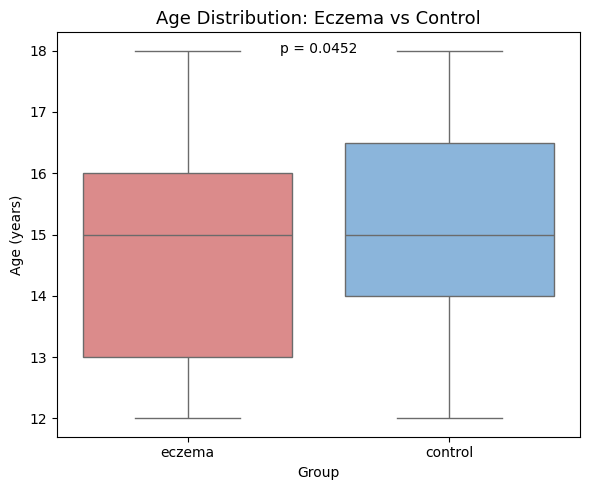

In [29]:
# Box plot comparing age distribution between eczema and control.
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=df, x='group_binary', y='Age', palette={'eczema': '#E87E7E', 'control': '#7EB6E8'}, ax=ax)

ax.set_title('Age Distribution: Eczema vs Control', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Age (years)')
ax.annotate(f'p = {age_p:.4f}', xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

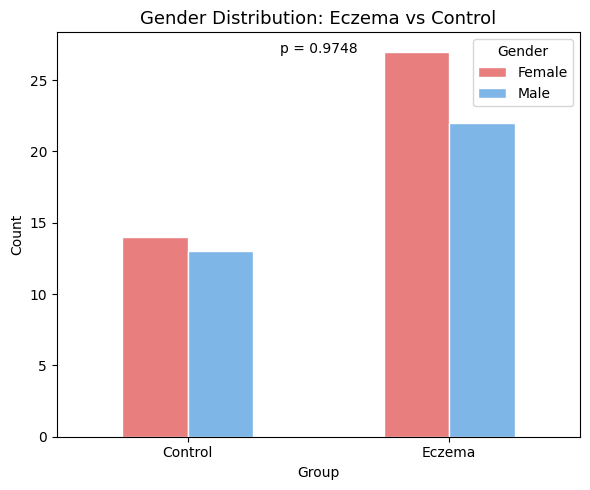

In [30]:
# Bar plot compared number of males and females in each group.
fig, ax = plt.subplots(figsize=(6, 5))

gender_counts = df.groupby(['group_binary', 'Male']).size().unstack()
gender_counts.columns = ['Female', 'Male']
gender_counts.plot(kind='bar', color=['#E87E7E', '#7EB6E8'], ax=ax, edgecolor='white')

ax.set_title('Gender Distribution: Eczema vs Control', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Count')
ax.set_xticklabels(['Control', 'Eczema'], rotation=0)
ax.legend(title='Gender')
ax.annotate(f'p = {gender_p:.4f}', xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\ryadl\AppData\Local\Temp\ipykernel_41444\1142428613.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Severe (1)', 'Moderate (2)'])


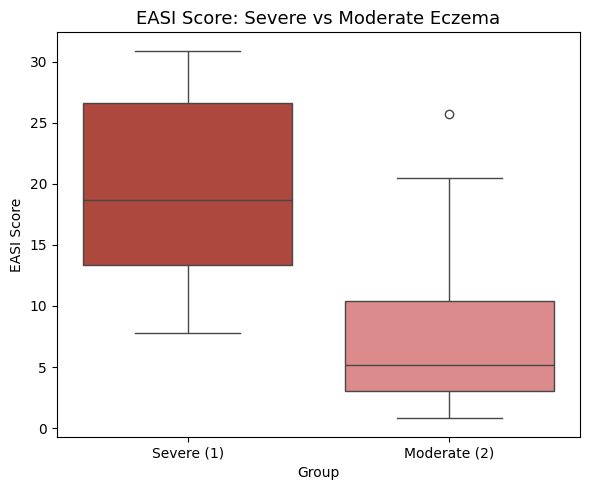

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=eczema, x='Group', y='EASI', hue='Group', palette=['#C0392B', '#E87E7E'], 
            legend=False, ax=ax)

ax.set_title('EASI Score: Severe vs Moderate Eczema', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('EASI Score')
ax.set_xticklabels(['Severe (1)', 'Moderate (2)'])

plt.tight_layout()
plt.show()

In [40]:
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal, fisher_exact
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Group setup ────────────────────────────────────────────────────────────
df['group_label'] = 'Group ' + df['Group'].astype(int).astype(str)

GROUP_ORDER   = ['Group 1', 'Group 2', 'Group 3']
GROUP_COLOURS = {
    'Group 1': '#E69F00',
    'Group 2': '#56B4E9',
    'Group 3': '#009E73',
}

g1 = df[df['group_label'] == 'Group 1']
g2 = df[df['group_label'] == 'Group 2']
g3 = df[df['group_label'] == 'Group 3']

# Age: Kruskal-Wallis across all three groups
age_stat, age_p = kruskal(
    g1['Age'].dropna(), g2['Age'].dropna(), g3['Age'].dropna()
)

# Gender: Chi-square on 3×2 table
gender_table = pd.crosstab(df['group_label'], df['Male'])
gender_chi2, gender_p, gender_dof, _ = chi2_contingency(gender_table)

# EASI: Mann-Whitney U — Group 1 vs Group 2 only
easi_g1 = pd.to_numeric(g1['EASI'], errors='coerce').dropna()
easi_g2 = pd.to_numeric(g2['EASI'], errors='coerce').dropna()
easi_stat, easi_p = mannwhitneyu(easi_g1, easi_g2, alternative='two-sided')

# Onset before 2: Fisher's exact — Group 1 vs Group 2 only
# (one cell count of 3 confirmed earlier, below chi-square threshold)
onset_table = pd.crosstab(
    df[df['group_label'].isin(['Group 1', 'Group 2'])]['group_label'],
    df[df['group_label'].isin(['Group 1', 'Group 2'])]['Onset before 2'].dropna()
)
onset_OR, onset_p = fisher_exact(onset_table)

print(f"Age:           H={age_stat:.2f}, p={age_p:.4f}  (Kruskal-Wallis)")
print(f"Gender:        chi2={gender_chi2:.2f}, df={gender_dof}, p={gender_p:.4f}  (Chi-square)")
print(f"EASI:          U={easi_stat:.1f}, p={easi_p:.4f}  (Mann-Whitney U)")
print(f"Onset <2 yrs:  OR={onset_OR:.2f}, p={onset_p:.4f}  (Fisher's exact)")
print(f"\nOnset before 2 contingency table:\n{onset_table}")

Age:           H=4.33, p=0.1150  (Kruskal-Wallis)
Gender:        chi2=0.09, df=2, p=0.9583  (Chi-square)
EASI:          U=378.5, p=0.0000  (Mann-Whitney U)
Onset <2 yrs:  OR=0.78, p=1.0000  (Fisher's exact)

Onset before 2 contingency table:
Onset before 2  0.0  1.0
group_label             
Group 1           3   10
Group 2          10   26


In [33]:
def fmt_mean_sd(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return f"{s.mean():.1f} ± {s.std():.1f}"

def fmt_pct_male(grp):
    col = pd.to_numeric(grp['Male'], errors='coerce').dropna()
    n, k = len(col), int(col.sum())
    return f"{k}/{n} ({k/n*100:.0f}%)"

table = pd.DataFrame({
    'Characteristic': ['n', 'Age, years', 'Male, n (%)', 'EASI score'],
    'Group 1':  [len(g1), fmt_mean_sd(g1['Age']), fmt_pct_male(g1), fmt_mean_sd(g1['EASI'])],
    'Group 2':  [len(g2), fmt_mean_sd(g2['Age']), fmt_pct_male(g2), fmt_mean_sd(g2['EASI'])],
    'Group 3':  [len(g3), fmt_mean_sd(g3['Age']), fmt_pct_male(g3), '—'],
    'p-value':  ['—', f'{age_p:.4f}', f'{gender_p:.4f}', f'{easi_p:.4f}'],
    'Test':     ['—', 'Kruskal-Wallis', 'Chi-square', 'Mann-Whitney U †'],
}).set_index('Characteristic')

print("=== Baseline Characteristics ===\n")
print(table.to_string())
print("\n† EASI comparison is Group 1 vs Group 2 only; Group 3 (control) has no EASI score.")

=== Baseline Characteristics ===

                   Group 1      Group 2      Group 3 p-value              Test
Characteristic                                                                
n                       13           36           27       —                 —
Age, years      14.1 ± 1.8   14.4 ± 1.6   15.2 ± 1.6  0.1150    Kruskal-Wallis
Male, n (%)     6/13 (46%)  16/36 (44%)  13/27 (48%)  0.9583        Chi-square
EASI score      19.7 ± 7.7    7.4 ± 6.2            —  0.0000  Mann-Whitney U †

† EASI comparison is Group 1 vs Group 2 only; Group 3 (control) has no EASI score.


In [45]:
from great_tables import GT, md, style, loc

def fmt_mean_sd(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return f"{s.mean():.1f} ± {s.std():.1f}"

def fmt_pct_male(grp):
    col = pd.to_numeric(grp['Male'], errors='coerce').dropna()
    n, k = len(col), int(col.sum())
    return f"{k}/{n} ({k/n*100:.0f}%)"

def fmt_pct_onset(grp):
    col = pd.to_numeric(grp['Onset before 2'], errors='coerce').dropna()
    if len(col) == 0:
        return '—'
    n, k = len(col), int(col.sum())
    return f"{k}/{n} ({k/n*100:.0f}%)"

table_df = pd.DataFrame({
    'Characteristic': ['Age, years', 'Male, n (%)', 'EASI score', 'Onset before age 2, n (%)'],
    'Group 1\n(AD + systemic therapy, n=13)': [
        fmt_mean_sd(g1['Age']),
        fmt_pct_male(g1),
        fmt_mean_sd(g1['EASI']),
        fmt_pct_onset(g1),
    ],
    'Group 2\n(AD, n=36)': [
        fmt_mean_sd(g2['Age']),
        fmt_pct_male(g2),
        fmt_mean_sd(g2['EASI']),
        fmt_pct_onset(g2),
    ],
    'Group 3\n(Control, n=27)': [
        fmt_mean_sd(g3['Age']),
        fmt_pct_male(g3),
        '—',
        '—',
    ],
    'p-value': [
        f'{age_p:.4f}',
        f'{gender_p:.4f}',
        f'{easi_p:.4f}',
        f'{onset_p:.4f}',
    ],
    'Test': [
        'Kruskal-Wallis',
        'Chi-square',
        'Mann-Whitney U †',
        "Fisher's exact †",
    ],
})

(
    GT(table_df)
    .tab_header(
        title='Table 1. Baseline Characteristics by Group',
        subtitle=md('Values are mean ± SD.')
    )
    .tab_source_note(
        md('† Comparison is Group 1 vs Group 2 only; Group 3 (control) has no EASI score or eczema onset data.')
    )
    .cols_label(Characteristic='Characteristic')
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.header()
    )
    .tab_style(
        style=style.fill(color='#F7F7F7'),
        locations=loc.body(rows=[1, 3])
    )
    .opt_table_font(font='Calibri')
    .opt_horizontal_padding(scale=2)
)

GT(_tbl_data=              Characteristic Group 1\n(AD + systemic therapy, n=13)  \
0                 Age, years                             14.1 ± 1.8   
1                Male, n (%)                             6/13 (46%)   
2                 EASI score                             19.7 ± 7.7   
3  Onset before age 2, n (%)                            10/13 (77%)   

  Group 2\n(AD, n=36) Group 3\n(Control, n=27) p-value              Test  
0          14.4 ± 1.6               15.2 ± 1.6  0.1150    Kruskal-Wallis  
1         16/36 (44%)              13/27 (48%)  0.9583        Chi-square  
2           7.4 ± 6.2                        —  0.0000  Mann-Whitney U †  
3         26/36 (72%)                        —  1.0000  Fisher's exact †  , _body=<great_tables._gt_data.Body object at 0x0000028BD33F4710>, _boxhead=Boxhead([ColInfo(var='Characteristic', type=<ColInfoTypeEnum.default: 1>, column_label='Characteristic', column_align='left', column_width=None), ColInfo(var='Group 1\n(AD + systemic therapy, n=13)', type=<ColInfoTypeEnum.default: 1>, column_label='Group 1\n(AD + systemic therapy, n=13)', column_align='left', column_width=None), ColInfo(var='Group 2\n(AD, n=36)', type=<ColInfoTypeEnum.default: 1>, column_label='Group 2\n(AD, n=36)', column_align='left', column_width=None), ColInfo(var='Group 3\n(Control, n=27)', type=<ColInfoTypeEnum.default: 1>, column_label='Group 3\n(Control, n=27)', column_align='left', column_width=None), ColInfo(var='p-value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='Test', type=<ColInfoTypeEnum.default: 1>, column_label='Test', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028BD2EC5ED0>, _spanners=Spanners([]), _heading=Heading(title='Table 1. Baseline Characteristics by Group', subtitle=Md(text='Values are mean ± SD.'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000028BD33A5410>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000028BD33A5DD0>, _source_notes=[Md(text='† Comparison is Group 1 vs Group 2 only; Group 3 (control) has no EASI score or eczema onset data.')], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Characteristic', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Group 1\n(AD + systemic therapy, n=13)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Group 2\n(AD, n=36)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Group 3\n(Control, n=27)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='p-value', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Test', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)

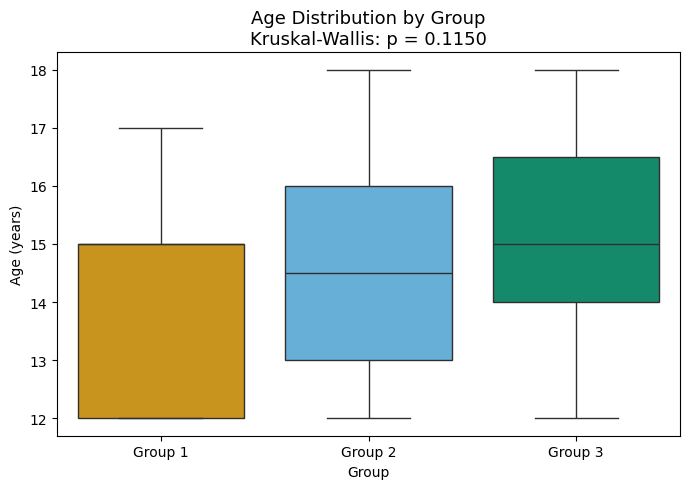

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df, x='group_label', y='Age',
    order=GROUP_ORDER,
    hue='group_label', palette=GROUP_COLOURS,
    hue_order=GROUP_ORDER, legend=False, ax=ax
)

ax.set_title(f'Age Distribution by Group\nKruskal-Wallis: p = {age_p:.4f}', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

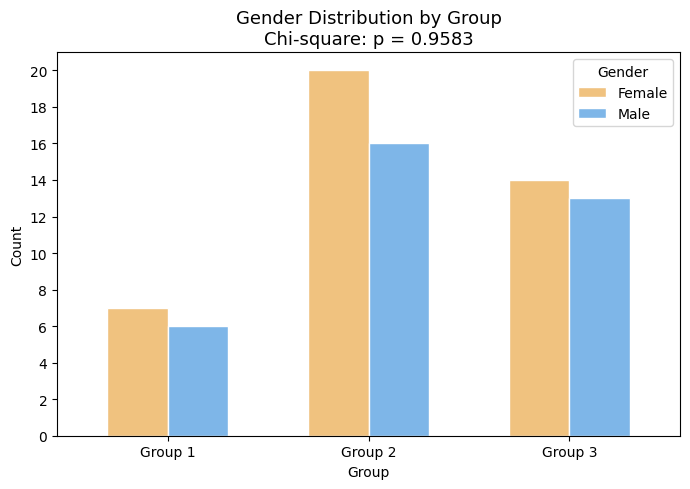

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

gender_counts = (
    df.groupby(['group_label', 'Male'])
    .size()
    .unstack()
    .reindex(GROUP_ORDER)
)
gender_counts.columns = ['Female', 'Male']
gender_counts.plot(
    kind='bar',
    color=['#F0C27F', '#7EB6E8'],   # neutral female/male colours, not group colours
    ax=ax, edgecolor='white', width=0.6
)

ax.set_title(f'Gender Distribution by Group\nChi-square: p = {gender_p:.4f}', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Count')
ax.set_xticklabels(GROUP_ORDER, rotation=0)
ax.set_yticks(np.arange(0,22,2))
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

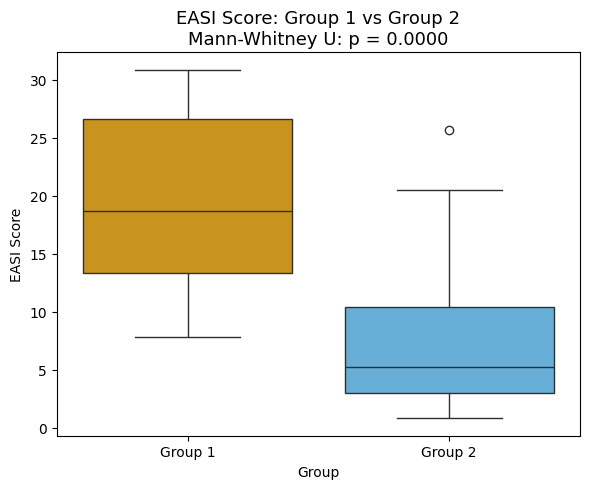

In [36]:
eczema = df[df['group_label'].isin(['Group 1', 'Group 2'])].copy()
eczema['EASI'] = pd.to_numeric(eczema['EASI'], errors='coerce')

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=eczema, x='group_label', y='EASI',
    order=['Group 1', 'Group 2'],
    hue='group_label', palette=GROUP_COLOURS,
    hue_order=['Group 1', 'Group 2'], legend=False, ax=ax
)

ax.set_title(
    f'EASI Score: Group 1 vs Group 2\nMann-Whitney U: p = {easi_p:.4f}',
    fontsize=13
)
ax.set_xlabel('Group')
ax.set_ylabel('EASI Score')
plt.tight_layout()
plt.show()